In [39]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.tree import DecisionTreeClassifier

In [3]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.sample(10)

,Survived,Age,Fare
168,0,NaN,25.9250
815,0,NaN,0.0000
269,1,35.0,135.6333
665,0,32.0,73.5000
612,1,NaN,15.5000
748,0,19.0,53.1000
653,1,NaN,7.8292
143,0,19.0,6.7500
98,1,34.0,23.0000
27,0,19.0,263.0000


In [4]:
df.dropna(inplace =True)

In [5]:
df.shape

(714, 3)

In [6]:
X=df.iloc[:,1:3]
y=df.iloc[:,0:1]

In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [8]:
X_train

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000
...,...,...
92,46.0,61.1750
134,25.0,13.0000
337,41.0,134.5000
548,33.0,20.5250


In [9]:
clf=DecisionTreeClassifier()
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6293706293706294

In [10]:
np.mean(cross_val_score(clf,X,y,scoring="accuracy",cv=10,))

np.float64(0.6303012519561815)

In [11]:
kbin_age = KBinsDiscretizer(
    n_bins=15,             
    encode='ordinal',      
    strategy='quantile'     
)

kbin_fare = KBinsDiscretizer(
    n_bins=15,             
    encode='ordinal',      
    strategy='quantile'     
)

In [12]:
trf = ColumnTransformer(
    transformers=[
        ('age_bin', kbin_age, [0]),
        ('fare_bin', kbin_fare, [1])
    ]
)


X_train_tr = trf.fit_transform(X_train)
X_test_tr = trf.transform(X_test)

clf = DecisionTreeClassifier()
clf.fit(X_train_tr, y_train.values.ravel())
y_pred = clf.predict(X_test_tr)
accuracy_score(y_test, y_pred)

0.6363636363636364

In [13]:
np.mean(cross_val_score(clf,X,y,scoring="accuracy",cv=10))

np.float64(0.6316901408450704)

In [37]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6317488262910798


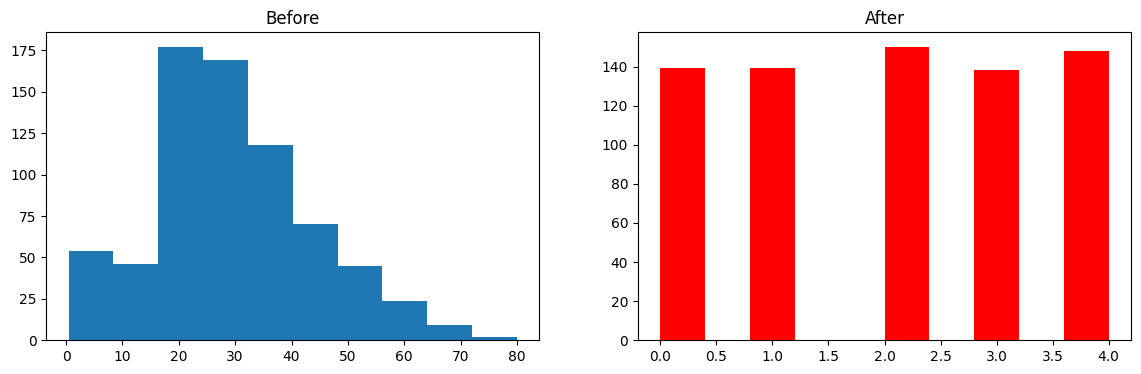

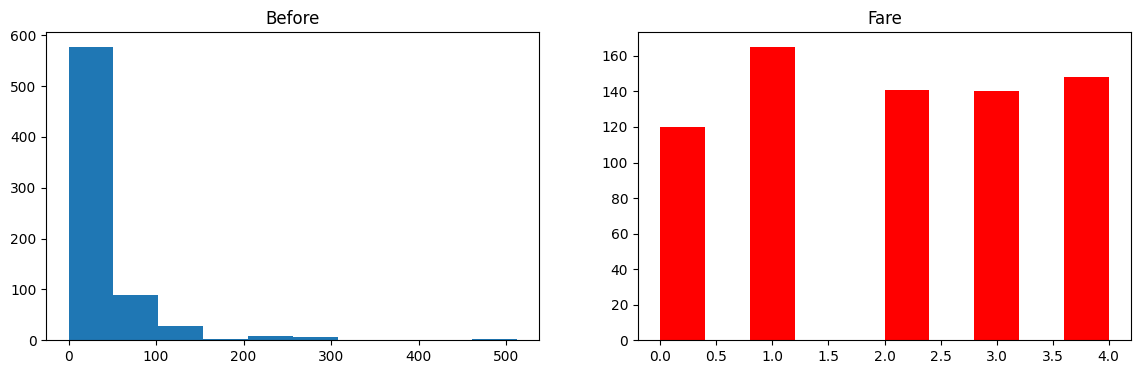

In [41]:
discretize(5,'quantile')